# MCMC case study: The 1861 measles outbreak in Hagelloch

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gem-epidemics/colab/blob/master/iddinf/mcmc_case_study.ipynb)

In this notebook, we'll use `gemlib` to analyse a carefully collected dataset of an outbreak of measles in the children of the German city of Hagelloch (near Tubingen) in 1861.  The dataset is remarkable in that it represents a census of children in the city, with the dates of onset of fever and rash recorded, as well as the household and school class to which they belonged, as well as the location of each child's house.

These data are described in detail in Neal and Roberts 2004, and our analysis is close to their original analysis (though omits the model selection procedure for brevity).  The data are available in the accompanying NetCDF4 file "hagelloch.nc", which we will load in below.

* Neal, PJ and Roberts GO (2004) Statistical inference and model selection for the 1861 Hagelloch measles epidemic. _Biostatistics_ __5__(2):249-61, [10.1093/biostatistics/5.2.249](https://doi.org/10.1093/biostatistics/5.2.249).

In [1]:
import urllib
from warnings import warn

try:
    import google.colab
    !pip install -Uq gemlib
except:
    warn("Not running in Colab, make sure `gemlib` is installed locally")

import gemlib
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
import tensorflow_probability.substrates.jax as tfp
import xarray as xr

%matplotlib inline

gld = gemlib.distributions
mcmc = gemlib.mcmc
tfd = tfp.distributions
tfb = tfp.bijectors

/tmp/ipykernel_887947/2838203406.py:8: UserWarning: Not running in Colab, make sure `gemlib` is installed locally
  warn("Not running in Colab, make sure `gemlib` is installed locally")


## Loading the data

First we'll load the data using Python's [`xarray`](https://docs.xarray.dev) package.  Since the dataset we need is on the web, we first download it, save the file locally, and then read it in using `xarray`.  Typically, you'd manually download the dataset, but to make things easier we'll use Python's `urllib` to automate the process.

In [2]:
url = "https://gem-epidemics.gitlab.io/practical-epidemics/_static/iddinf/hagelloch.nc"
local_path="hagelloch.nc"

# Download the dataset to local disk
urllib.request.urlretrieve(url, local_path)

# Load into an XArray Dataset
hagelloch = xr.load_dataset(local_path)
hagelloch

<xarray.Dataset> Size: 1MB
Dimensions:        (node_id: 187, parent_id: 187)
Coordinates:
  * node_id        (node_id) int32 748B 1 2 3 4 5 6 ... 182 183 184 185 186 187
    parent_id      (node_id) int32 748B 1 2 3 4 5 6 ... 182 183 184 185 186 187
Data variables:
    household_mat  (node_id, parent_id) float64 280kB 0.0 1.0 1.0 ... 0.0 0.0
    class1_mat     (node_id, parent_id) float64 280kB 0.0 1.0 0.0 ... 0.0 0.0
    class2_mat     (node_id, parent_id) float64 280kB 0.0 0.0 0.0 ... 0.0 0.0
    distance_mat   (node_id, parent_id) float64 280kB 0.0 0.0 0.0 ... 37.12 0.0
    si_time        (node_id) int32 748B 22 24 29 28 23 27 ... 12 0 34 23 38 24
    ir_time        (node_id) int32 748B 30 32 37 33 32 34 ... 20 11 42 31 46 32
Attributes:
    description:  Data on the 1861 measles outbreak in Hagelloch, taken from ...

````{exercise} 
:label: mcmc-case-study-ex-1

Visualise the contact and distance matrices so you know what's going on.

```{tip}
Use Matplotlib's `imshow` method with the `origin="lower"` argument to plot a neat heatmap of the matrix
```

````

```{solution-start} mcmc-case-study-ex-1
:class: dropdown
```

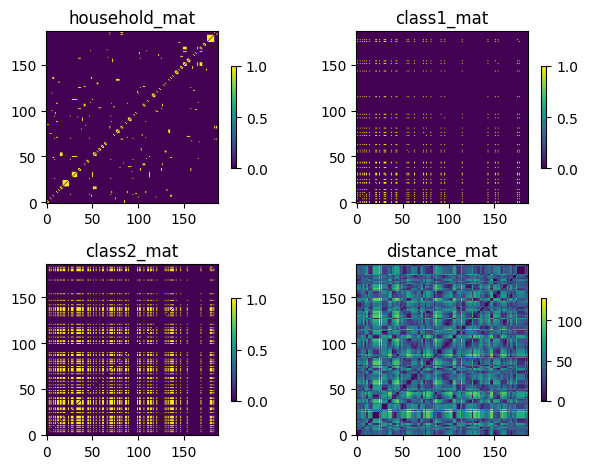

In [3]:
fig, axs = plt.subplots(2,2)
mats = ["household_mat", "class1_mat", "class2_mat", "distance_mat"]

for i, (mat, ax) in enumerate(zip(mats, axs.flatten())):
    im = ax.imshow(hagelloch[mat], origin="lower")
    ax.set_title(mat)
    fig.colorbar(im, ax=ax, shrink=0.6)

fig.tight_layout()

```{solution-end}
```

## Generate a discrete-time `gemlib` event list

The dataset we have just loaded contains two timeseries: `si_time` and `ir_time`, which we'll assume corresponds to the respective transitions in an SIR model.  Though this is a natural way to tabulate such data, `DiscreteTimeStateTranstionModel` requires that we supply our event list as a `[T, N, R]`-shaped tensor for `T` timepoints, `N` individuals, and `R=2` transitions.  That is, each `events[t, n, :]` slice is an array of length 2 with at most one element equal to 1 (since for each individual we could have either a S->I or a I->R transition or nothing.

Fortunately, this is very easy with Numpy -- we just create a `[T, N, 2]` tensor of zeros, then fill in the respective `[t,n,r]` coordinates by indexing using the times supplied in the dataset.

```{exercise}
:label: mcmc-case-study-ex-2

Explore both the `si_time` and `ir_time` data arrays:

* How many individuals (`N`) are represented?
* What is the time range (`T`) represented?

```


```{solution-start} mcmc-case-study-ex-2
:class: dropdown
```

In [4]:
num_individuals = hagelloch["si_time"].shape[0]
min_time = np.minimum(hagelloch["si_time"].min().data, hagelloch["ir_time"].min().data)
max_time = np.maximum(hagelloch["si_time"].max().data, hagelloch["ir_time"].max().data)

print("Num individuals: ", num_individuals)
print("Min time: ", min_time)
print("Max time: ", max_time)

Num individuals:  187
Min time:  0
Max time:  54


What we learn from the above is that the first event happens at time 0, with the final event happening at time 54.  There are 187 individuals.

```{solution-end}
```

### Encoding of the event list

Here's a recipe for constructing a `DiscreteTimeStateTransitionModel` event list given the event time data presented in the `hagelloch` dataset. 

If we condition on the initial infection at time 0, then we need to model what happens subsequently, i.e. for all timepoints $t=1,\dots,54$.  With 2 possible transitions to represent, and including the first infection which we'll remove later (it's easier), we will need an (empty) array of size `[max_time + 1, num_individuals, 2]` to hold our encoded event list:

In [5]:
events = np.zeros((max_time+1, num_individuals, 2))

We'll take advantage of Numpy fancy indexing to fill in the `[t, n, 0]` and `[t, n, 1]` elements with 1s for each time an event happened.  Note that this is _not_ allowed in JAX, because JAX is pure functional (you can't modify data, only create/copy data).

In [6]:
# S->I events
events[hagelloch["si_time"], np.arange(num_individuals), 0] = 1.0

# I->R events
events[hagelloch["ir_time"], np.arange(num_individuals), 1] = 1.0

# Take off the initial infection time, since we need to condition on this
events = events[1:] # N.B. this is shorthand for events[1:, :, :]

# While we're at it, we'll build a vector to represent the initial conditions
# across our 3 states, S, I, and R.
initial_conditions = np.zeros((num_individuals, 3))
initial_conditions[:, 0] = 1.0 # Initialise all individuals to susceptible
initial_infec_idx = np.where(hagelloch["si_time"] == 0)[0]
initial_conditions[initial_infec_idx,:] = [0.0, 1.0, 0.0] # Set initial infective

````{exercise}
:label: mcmc-case-study-ex-2.5

Given the event tensor we've just constructed, plot the total event incidence timeseries, i.e. the number of S->I and I->R events that happen each day summing over all individuals.

```{tip}
Use the `.sum(axis=...)` method on the events tensor to aggregate individuals.
```
````

```{solution-start} mcmc-case-study-ex-2.5
:class: dropdown
```

Here we plot the S->I and I->R events by slicing the right-most dimension of `events` corresponding to each transition, and then sum over the `N` dimension (which becomes the righthand dimension after slicing, hence the `axis=-1` argument to `.sum()`)

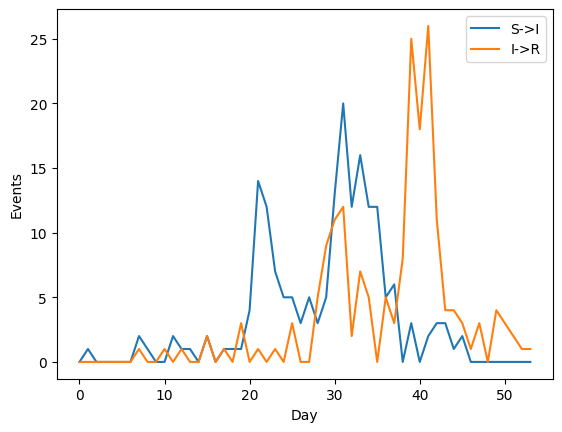

In [7]:
plt.plot(events[...,0].sum(axis=-1), label="S->I")
plt.plot(events[...,1].sum(axis=-1), label="I->R")
plt.legend()
plt.xlabel("Day")
plt.ylabel("Events");

```{solution-end}
```

## Building the epidemic model

As previously in these notes, we'll use `DiscreteTimeStateTransitionModel` to build a discrete-time analogue of the model proposed in [Neal and Roberts (2004)](https://doi.org/10.1093/biostatistics/5.2.249).  We'll enclose this model in a factory function so we can embed it into a Bayesian model later.  We'll assume an SIR model in which the transition rates are

\begin{align}
\lambda^{SI}(t, x_t) & = & \left(\beta_1 M_h + \beta_2 M_{c1} + \beta_3 M_{c2} + \beta_4 e^{-\delta (M_d - \kappa)}\right) \cdot x^{I}_t \\
\lambda^{IR}(t, x_t) & = & \gamma
\end{align}

where $M_h$, $M_{c1}$, $M_{c2}$, and $M_d$ represent the household, class 1, class2, and distance connectivity matrices with associated coefficients $\beta_1,\dots,\beta_4$, and assuming an exponentially-decaying infection rate with inter-household distance decaying at rate $\delta$.

```{note}
$\kappa$ is a centering constant that we apply to break down a positive correlation between $\beta_4$ and $\delta$ that you would otherwise get.   Unfortunately, there is no analytical way to choose $\kappa$, and we typically choose it by experimentation.
```

Let's now code this using `gemlib`:

In [8]:
sir_incidence_matrix = [[-1, 0], [1, -1], [0, 1]]

def hagelloch_sir(
    household, 
    class1, 
    class2, 
    distance, 
    spatial_decay, 
    removal_rate, 
    initial_conditions, 
    name="sir"
):

    def si_rate(t, state):

        kappa = 30.0
        total_connectivity = (
            household * hagelloch["household_mat"].data
            + class1 * hagelloch["class1_mat"].data
            + class2 * hagelloch["class2_mat"].data
            + distance * jnp.exp(-spatial_decay * (hagelloch["distance_mat"].data-kappa))
        )

        return jnp.matvec(total_connectivity, state[:,1])

    def ir_rate(t, state):
        return removal_rate
        
    return gld.DiscreteTimeStateTransitionModel(
        transition_rate_fn=[si_rate, ir_rate],
        incidence_matrix=sir_incidence_matrix,
        initial_state=initial_conditions,
        num_steps=54,
        name=name,
    )

Okay, let's test out the model to see if it runs, and gives us halfway sensible answers.

In [9]:
sir_model = hagelloch_sir(
    household=0.01, 
    class1=0.04, 
    class2=0.01, 
    distance=0.001, 
    spatial_decay=0.01, 
    removal_rate=0.14, 
    initial_conditions=initial_conditions
)

In [10]:
sim_events = sir_model.sample(seed=jax.random.key(42))

```{note}
I've made these test parameters up, based on the inference we do later.  Obviously, in real life you may need to play with the parameters to get sensible model output.
```

````{exercise}
:label: mcmc-case-study-ex-3

Given the output above, see if you can plot:

1. The total event incidence, i.e. the number of S->I and I->R events that happen each day summing over all individuals.
2. The total prevalence of S, I, and R individuals each day.

```{tip}
Use the `.sum(axis=...)` method on the events tensor to aggregate individuals, and use the `.compute_state()` method given by `DiscreteTimeStateTransitionModel` to compute the SIR state timeseries.
```

````

```{solution-start} mcmc-case-study-ex-3
:class: dropdown
```

1. We'll start by plotting both the S->I and I->R events on a single set of axes.  We do this with two calls to `plt.plot`, supplying first the S->I event slice, and then the I->R event slice.  Each time, we call `.sum(axis=-1)`, because the `N` axis is the _rightmost_ dimension of the sliced event tensor.

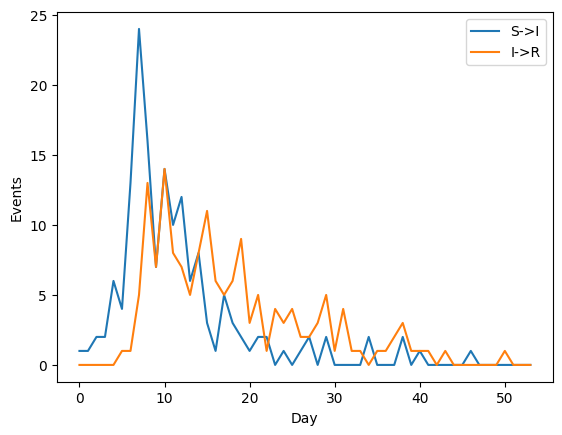

In [11]:
plt.plot(sim_events[...,0].sum(axis=-1), label="S->I")
plt.plot(sim_events[...,1].sum(axis=-1), label="I->R")
plt.legend()
plt.xlabel("Day")
plt.ylabel("Events");

2. We now compute the state trajectory, and plot the values of the S, I, and R states for each timepoint as we did previously for the events tensor.

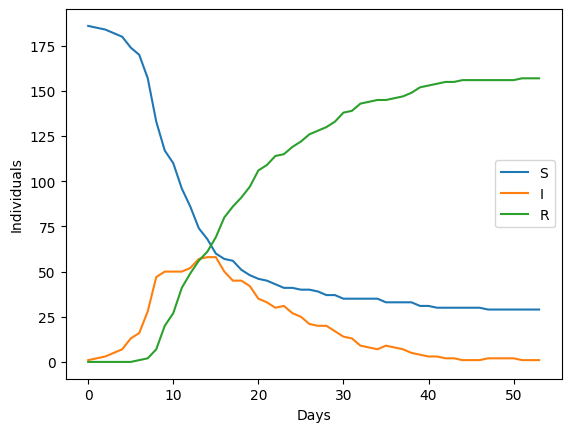

In [12]:
sim_state = sir_model.compute_state(sim_events)
plt.plot(sim_state[...,0].sum(axis=-1), label="S")
plt.plot(sim_state[...,1].sum(axis=-1), label="I")
plt.plot(sim_state[...,2].sum(axis=-1), label="R")
plt.legend()
plt.xlabel("Days")
plt.ylabel("Individuals");

```{solution-end}
```

## A Bayesian model

Now that we have a working individual-level model for our Hagelloch measles epidemic, we could do with fitting it to the observed data in order to discover the contributions of the various modes of infection transmission we have connectivity data for.  As we're doing our inference in a Bayesian context, we'll need to first construct a _joint probability model_. We'll impose the following prior distributions on our parameters:

\begin{align}
\beta_1 & \sim \mbox{Exponential}(10.0) \\
\beta_2 & \sim \mbox{Exponential}(10.0) \\
\beta_3 & \sim \mbox{Exponential}(10.0) \\
\beta_4 & \sim \mbox{Exponential}(10.0) \\
\delta & \sim \mbox{Exponential}(10.0) \\
\gamma & \sim \mbox{Exponential}(10.0) \\
x_{i,0} & \sim \mbox{Multinomial}(1, (0.99, 0.01, 0.0)^\intercal), \; i = 1, \dots, N
\end{align}

Note that since we one-hot encode the initial state of each individual (i.e. before our time window starts), we place _a priori_ independent Multinomial distributions over $(S, I, R)^\intercal$ for each individual $i$.


In [13]:
@tfd.JointDistributionCoroutineAutoBatched
def joint_model():

    household = yield tfd.Exponential(np.float64(10.0), name="household")
    class1 = yield tfd.Exponential(np.float64(10.0), name="class1")
    class2 = yield tfd.Exponential(np.float64(10.0), name="class2")
    distance = yield tfd.Exponential(np.float64(10.0), name="distance")
    spatial_decay = yield tfd.Exponential(np.float64(20.0), name="spatial_decay")
    removal_rate = yield tfd.Exponential(np.float64(10.0), name="removal_rate")
    
    # tfd.Sample creates independent samples from 
    # the wrapped distribution, but computes their
    # joint log-probability function.
    initial_conditions = yield tfd.Sample(
        tfd.Multinomial(1, probs=np.array([0.99, 0.01, 0.0])),
        sample_shape=hagelloch["si_time"].shape[0],
        name="initial_conditions",
    )

    sir = yield hagelloch_sir(
        household, 
        class1, 
        class2, 
        distance, 
        spatial_decay, 
        removal_rate, 
        initial_conditions, 
        name="sir",
    )

```{note}
This dataset is particularly numerically unstable if we use single precision (`np.float32`) arithmetic.  In the above example, we've explicitly set the type of the random variables to be double precision, by annotating their parameters with `np.float64()`.
```

Let's quickly check that our joint model runs by taking a draw from the joint prior distribution

In [14]:
prior_sample = joint_model.sample(seed=jax.random.key(42))

### Building the MCMC algorithm

#### Infection times assumed known

Armed with a fully-specified Bayesian model, we now need to build a suitable MCMC algorithm to sample from the joint posterior distribution conditioned on the observed data.  We'll assume that all transition times are known for now, meaning that the initial conditions are also known. We'll relax this assumption for the S->I transitions later on, however.

We will construct our MCMC algorithm as a single-site Metropolis-within-Gibbs sampler, sequentially employing Random walk Metropolis Hastings to sample from the conditional posterior of each parameter in turn.  Since all our transmission parameters, ($\beta_1, \dots, \beta_4, \delta, \gamma$) have non-zero support (i.e. they cannot be negative), we will _transform_ the vanilla RWMH algorithm to a _logarithmic_ random walk.

The first step is to construct the joint posterior (up to a normalising constant) by "pinning" the joint model with the observed data -- in this case the event timeseries and initial conditions.

```{note}
One important thing to do is to ensure that the log posterior density evaluates to a finite value, else the MCMC will never be able to successfully accept a proposal [^1].  In practice, it may take a bit of fiddling with the initial values of the parameters to achieve this.

[^1]: You might like to study the accept/reject ratio formula to understand why this is.

```

In [15]:
conditional_model = joint_model.experimental_pin(sir=events, initial_conditions=initial_conditions)
prior_sample = conditional_model.sample_unpinned(seed=jax.random.key(43))

conditional_model.log_prob(prior_sample)

Array(-3748.18451509, dtype=float64)

Excellent!  We have a finite value for the log posterior distribution given the event timeseries and initial conditions.

Let's now build the Metropolis-within-Gibbs samples.  Since each parameter takes non-zero support and requires a similar transformed sampler, we'll build a factory function to save us a bit of code.  Notice how we wrap the `mcmc.rwmh` sampler inside `mcmc.transform_sampling_algorithm`, which is in turn wrapped inside `mcmc.MwgStep`.

In [16]:
def log_rwmh(param_name, scale):
    return mcmc.MwgStep(
        mcmc.transform_sampling_algorithm(
            bijectors=tfb.Exp(),
            sampling_algorithm=mcmc.rwmh(
                scale=scale,
            )
        ),
        target_names=param_name,
    )

param_kernel = (
    log_rwmh("household", 0.5)
    >> log_rwmh("class1", 0.5)
    >> log_rwmh("class2", 0.5)
    >> log_rwmh("distance", 0.4)
    >> log_rwmh("spatial_decay", 1.2)
    >> log_rwmh("removal_rate", 0.25)
)

Let's run the sampler using `jax.jit` for speed.

In [65]:
@jax.jit
def sampler1(seed):
    return mcmc.mcmc(
        num_samples=5000,
        sampling_algorithm=param_kernel,
        target_log_density_fn=conditional_model.log_prob,
        initial_position=conditional_model.sample_unpinned(seed=jax.random.key(43)),
        seed=seed,
    )

%time samples, info = sampler1(jax.random.key(42))

CPU times: user 26.6 s, sys: 5.79 s, total: 32.4 s
Wall time: 21 s


```{exercise}
:label: mcmc-case-study-ex-4

Having obtained the samples for our parameters:

1.  Compute the acceptance rate for each of the component RWHM kernels using the `info` list.  
2.  Draw traceplots, kernel density plots, and ACF plots.
3.  Calculate the effective sample size and Gelman-Rubin diagnostic for each chain.
4.  Interpret the results.
```

```{solution-start} mcmc-case-study-ex-4
```

Acceptance rates -- note that since the component RWMH map onto single parameters, we can iterate of the list of parameter names.

In [66]:
param_names = ["household", "class1", "class2", "distance", "spatial_decay", "removal_rate"]

for i, k in enumerate(param_names):
    print(f"Acceptance rate for '{k}' kernel: {info[i].is_accepted.mean()}")

Acceptance rate for 'household' kernel: 0.4429999887943268
Acceptance rate for 'class1' kernel: 0.44339999556541443
Acceptance rate for 'class2' kernel: 0.48099997639656067
Acceptance rate for 'distance' kernel: 0.3893999755382538
Acceptance rate for 'spatial_decay' kernel: 0.5719999670982361
Acceptance rate for 'removal_rate' kernel: 0.33379998803138733


Traceplots, kernel density plots, and ACF plots:

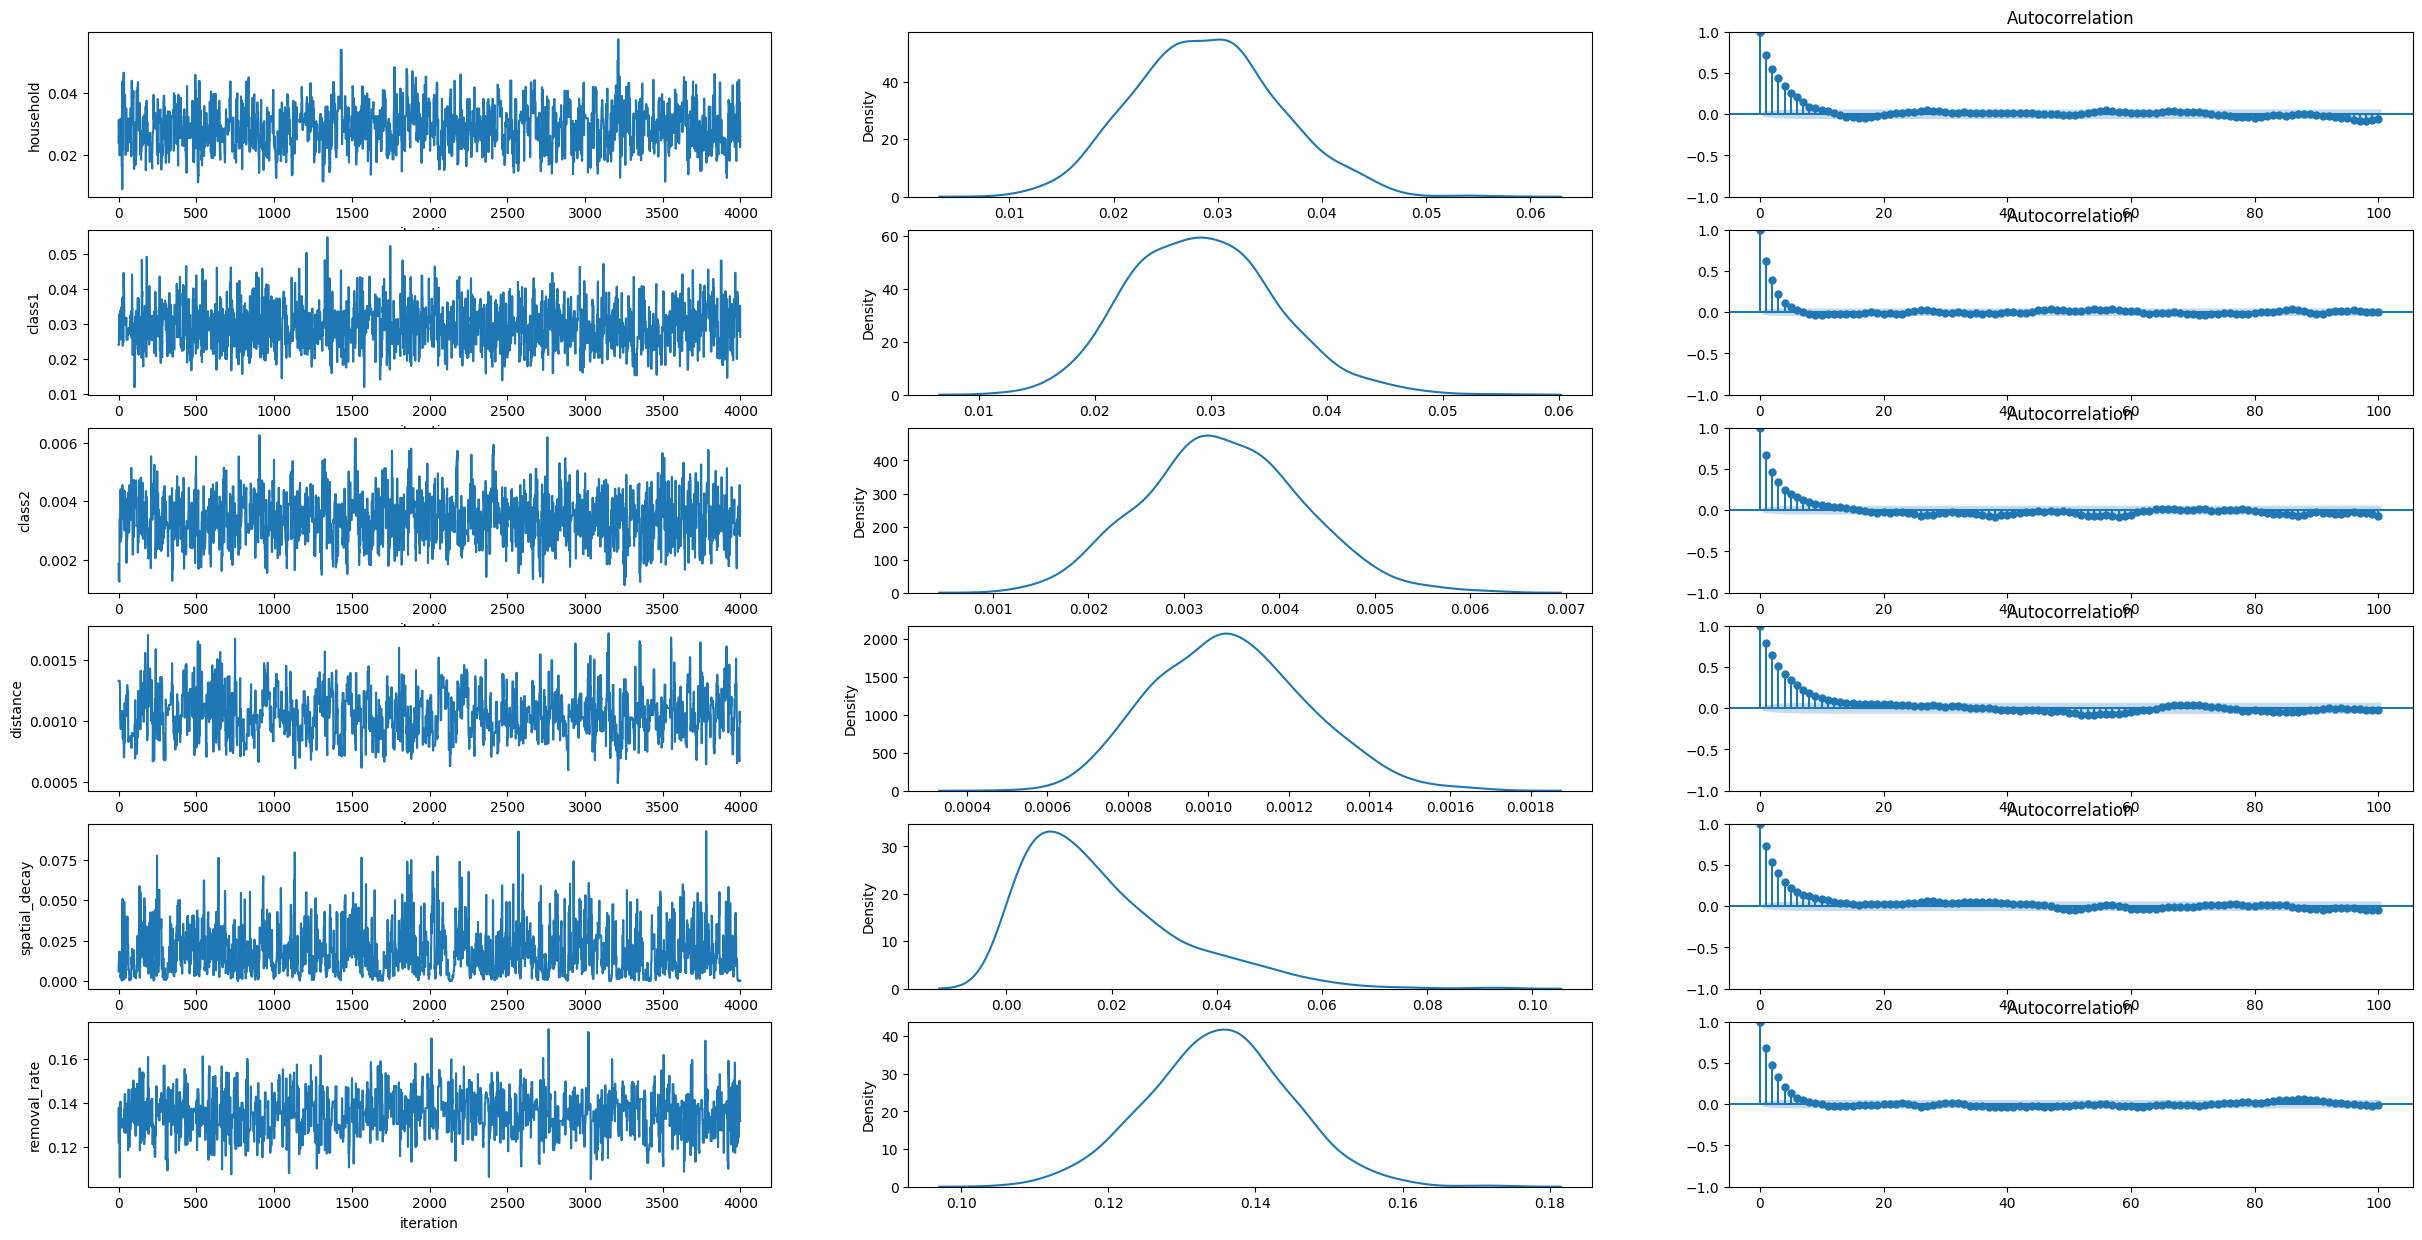

In [67]:
fig, axs = plt.subplots(len(info), 3, figsize=(5*len(info), 15))

for s, n, a in zip(samples, param_names, axs):
    s_ = s[1000:] # remove burnin
    a[0].plot(s_, label=n)
    a[0].set_ylabel(n)
    a[0].set_xlabel("iteration")
    sns.kdeplot(s_, ax=a[1], bw_adjust=1.5) # inflate bandwidth because of 0.44 acceptance rate
    plot_acf(s_, ax=a[2], lags=100)

Effective sample size:

In [68]:
ess = jax.tree.map(lambda x: tfp.mcmc.effective_sample_size(x[1000:]), samples)
print(ess)

StructTuple(
  household=Array(582.34163493, dtype=float64),
  class1=Array(1034.20749653, dtype=float64),
  class2=Array(643.32084589, dtype=float64),
  distance=Array(384.17228296, dtype=float64),
  spatial_decay=Array(424.59720281, dtype=float64),
  removal_rate=Array(798.9782473, dtype=float64)
)


The quality of the inference looks okay, with visually acceptable traceplots, and a reasonably high ESS considering we are using separate (logarithmic) RWMH samplers.  We could make use of gradient-based samplers to improve on this, and you may wish to try with `gemlib.mcmc.adaptive_hmc` to see if you can improve things. 

```{solution-end}
```

To round off this section, we'll construct the in-sample predictive distribution for the epidemic, conditional on the initial conditions, which amounts to simulating from the model for sampels from the joint posterior -- in other words, taking related parameter values within a single iteration of the MCMC.  To do this, we'll accelerate the computation using `jax.vmap`, allowing us to map the original joint model over the posterior.

In [69]:
posterior_predictive_sampler = jax.vmap(
    lambda **kwargs: joint_model.sample(**kwargs, initial_conditions=initial_conditions)
)

pp_samples = posterior_predictive_sampler(
    household=samples.household[::50],
    class1=samples.household[::50],
    class2=samples.household[::50],
    distance=samples.household[::50],
    spatial_decay=samples.household[::50],
    removal_rate=samples.household[::50],
    seed=jax.random.split(jax.random.key(44), samples.household[::50].shape[0]),
)

The first line of the previous cell is worth a little explanation. `jax.vmap` takes a function that usually requires scalar arguments, and turns it into a function that can vectorize over vector-values arguments.  The `**kwargs` in the Python `lambda` function is a shorthand for "collect all the named arguments together and dump them into `joint_model.sample()`".  We then run the sampler over the posterior, taking every 50th sample, and also providing random seeds for each selected sample.

Let's see the shape of the event timeseries we get out, which if you remember is called `sir` in the original joint model.

In [70]:
pp_samples.sir.shape

(100, 54, 187, 2)

So we have 100 simulations from our model, really rather quickly!  Let's plot them against the original data.

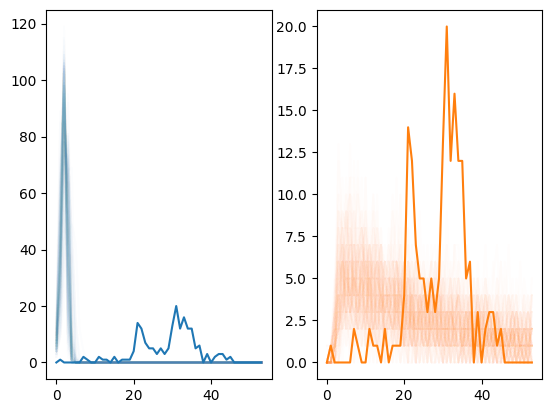

In [71]:
fig, axs = plt.subplots(1, 2)
axs[0].plot(pp_samples.sir[...,0].sum(axis=-1).T, color="C0", alpha=0.01)
axs[0].plot(events[...,0].sum(axis=-1), color="C0", label="S->I")
axs[1].plot(pp_samples.sir[...,1].sum(axis=-1).T, color="C1", alpha=0.01)
axs[1].plot(events[...,0].sum(axis=-1), color="C1", label="I->R")

Hmm, interesting.  We can definitely see that we're not quite capturing the peak of the epidemic.  This could be due to many factors, not least the imputation of the infection times, which may well be highly inaccurate.

### Incorporating data augmentation

In this section, we'll add a censored events sampler to the MCMC, allowing us to mix not only over individual's S->I event times, but also the initial conditions.  We'll see what effect it has on the inference and predictive distribution.  The algorithm we will use goes like this:

1. Draw $\beta_1,\dots,\beta_4,\delta,\gamma$ by log RWMH
2. For $i$ in $1,\dots,5$ do:
    1. Move a random infection time
    2. Update the initial conditions
3. Goto 1.

To do this, we need to set up two kernels: an instance of `mcmc.discrete_time_state_transition_model.move_events` and an instance of `mcmc.discrete_time_state_transition_model.left_censored_events_mh`.  See the [documentation](https://gem-epidemics.gitlab.io/gemlib/gemlib.mcmc.html#discrete-time-state-transition-model-kernels) for more information on the various kernel constants used to set them up.

In [80]:
move_kernel = mcmc.MwgStep(
    mcmc.discrete_time_state_transition_model.move_events(
        incidence_matrix=np.array(sir_incidence_matrix),
        transition_index=0,
        num_units=1,
        delta_max=5,
        count_max=1,
    ),
    target_names="sir",
    kernel_kwargs_fn=lambda p: {"initial_conditions": p.initial_conditions},
)

left_censored_kernel = mcmc.MwgStep(
    mcmc.discrete_time_state_transition_model.left_censored_events_mh(
        incidence_matrix=np.array(sir_incidence_matrix),
        transition_index=0,
        max_timepoint=10,
        max_events=1,
        events_varname="sir",
        initial_conditions_varname="initial_conditions",
    ),
    target_names=["initial_conditions", "sir"],
)

censored_kernel = param_kernel >> 5 * (move_kernel >> left_censored_kernel)

Notice that we didn't have to re-define the kernel for the parameters.  We just added on our two kernels that move infection times and account for left censoring.

Since we're now updating _all_ the distributions we defined in the joint model (even if we're only updating part of the `sir` distribution), our target log probability density function is the same as for the original `joint_model`:

In [81]:
# Get a starting point for the MCMC
initial_mcmc_position = joint_model.sample(sir=events, initial_conditions=initial_conditions, seed=jax.random.key(45))

# Check we get a finite log joint density value
joint_model.log_prob(initial_mcmc_position)

Array(-13667.6608597, dtype=float64)

Again, we have a finite value for our log probability function, so we can go ahead an invoke the kernel.  Be prepared to go for coffee while the machine crunches -- the censored data kernels take a lot of number crunching!

In [82]:
@jax.jit
def sampler2(seed):
    return mcmc.mcmc(
        num_samples=5000,
        sampling_algorithm=censored_kernel,
        target_log_density_fn=joint_model.log_prob,
        initial_position=initial_mcmc_position,
        seed=seed,
    )

%time samples, info = sampler2(jax.random.key(45))

CPU times: user 2min 1s, sys: 484 ms, total: 2min 2s
Wall time: 2min 4s


```{warning}
As you'll see when you draw the traceplots in the next exercise, I've economised on the number of iterations we really need for this data-augmentation MCMC algorithm for the sake of a quick results during a workshop.  [Experiments suggest](https://projecteuclid.org/journals/bayesian-analysis/volume-4/issue-3/Bayesian-analysis-for-emerging-infectious-diseases/10.1214/09-BA417.full) that updating about 10% of the infection times is optimal (the number of `move_kernel >> left_censored_kernel` repetitions), and that many more MCMC iterations than 5000 are needed to make satisfactory inference.
```

```{exercise}
:label: mcmc-case-study-ex-5

Once the MCMC has finished running, examine the output as above.  In particular, check out (and plot, like for the predictive distribution above) the posterior over the number of events.  Does this look more convincing that the "data free" version we plotted above?  Why is this?

```

```{solution-start} mcmc-case-study-ex-5
:class: dropdown
```

I will leave it to the reader to compute the traceplots

As before, let's check the acceptance rates.  Since our kernel is in fact nested (household >> class1 >> class2 >> distance >> spatial_decay >> removal_rate >> 20 * (move_kernel >> left_censored_kernel)), we have to be a little careful.  Nonetheless, we can get the acceptance rates of the transition parameters using the previous script:

In [83]:
for i, k in enumerate(param_names):
    print(f"Acceptance rate for '{k}' kernel: {info[i].is_accepted.mean()}")

Acceptance rate for 'household' kernel: 0.3985999822616577
Acceptance rate for 'class1' kernel: 0.4490000009536743
Acceptance rate for 'class2' kernel: 0.5852000117301941
Acceptance rate for 'distance' kernel: 0.3823999762535095
Acceptance rate for 'spatial_decay' kernel: 0.5795999765396118
Acceptance rate for 'removal_rate' kernel: 0.3369999825954437


For the compound `multi_scan` kernel (instatiated by requesting 20 repetitions of our two censored data samplers), we have to dig a little deeper:

In [84]:
print("Acceptance rate for move_kernel: ", info[6].last_results[0].is_accepted.mean())
print("Acceptance rate for left censored kernel: ", info[6].last_results[1].is_accepted.mean())

Acceptance rate for move_kernel:  0.39159998
Acceptance rate for left censored kernel:  0.99359995


The `move_kernel` looks fine, but our `left_censored_kernel` acceptance rate is high.  Unfortunately, there's not a huge amount we can do about this due to how the kernel works, but we'll move on regardless.

Let's see what the traceplots look like...

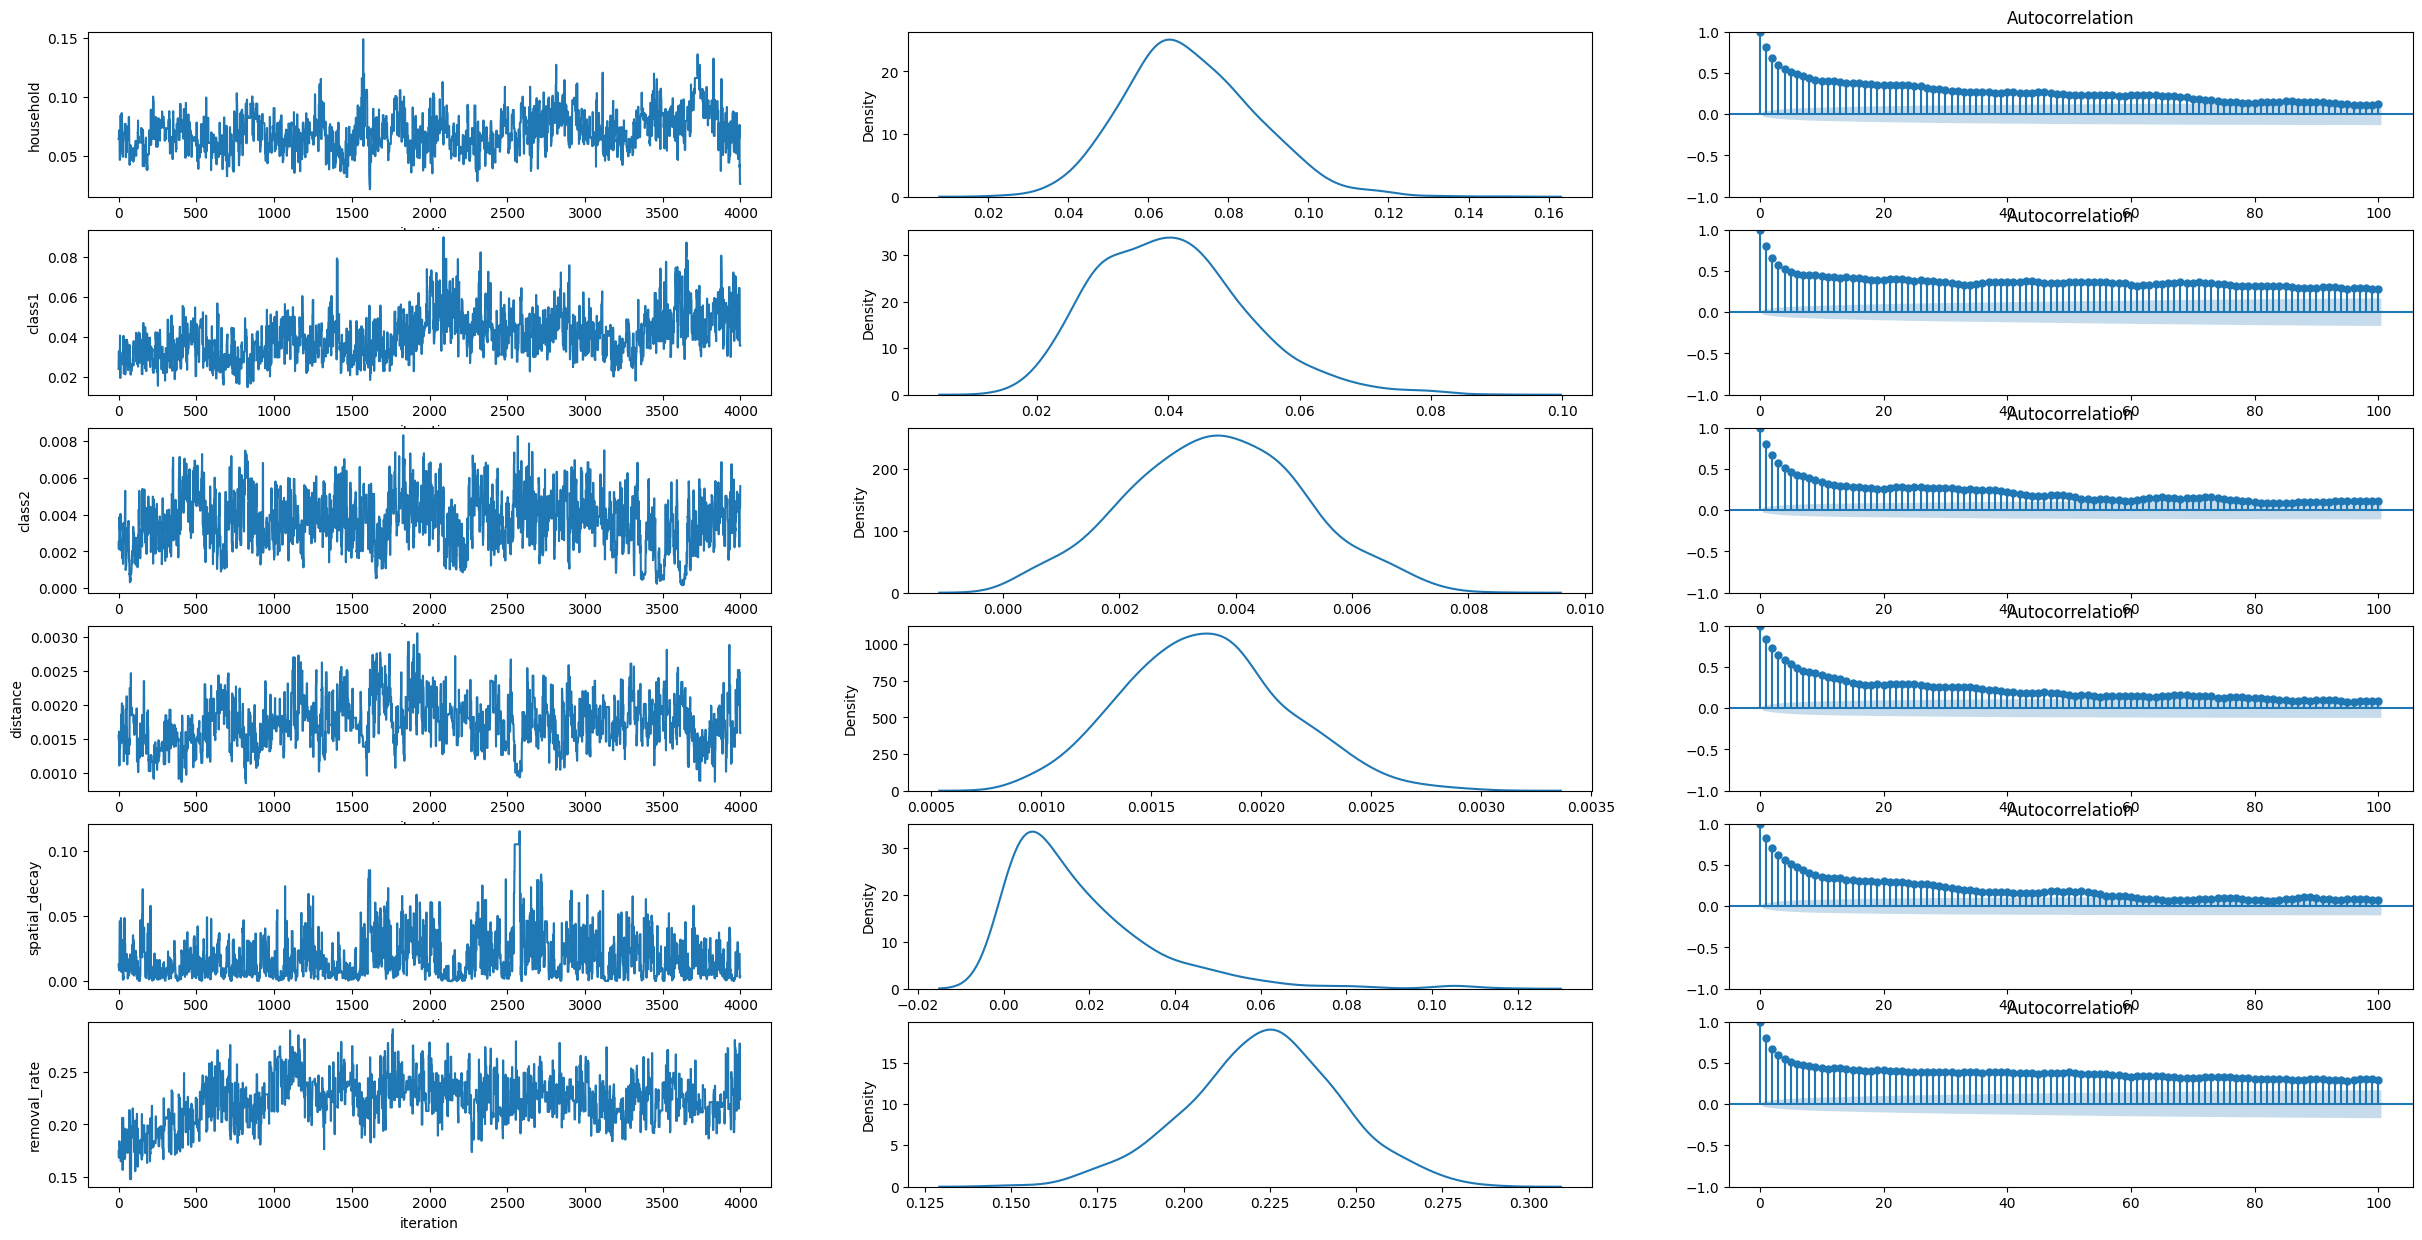

In [85]:
fig, axs = plt.subplots(len(info)-1, 3, figsize=(5*(len(info)-1), 15))

for s, n, a in zip(samples, param_names, axs):
    s_ = s[1000:] # remove burnin
    a[0].plot(s_, label=n)
    a[0].set_ylabel(n)
    a[0].set_xlabel("iteration")
    sns.kdeplot(s_, ax=a[1], bw_adjust=1.5) # inflate bandwidth because of 0.44 acceptance rate
    plot_acf(s_, ax=a[2], lags=100)

Interestingly, the quality of the MCMC mixing isn't nearly as good as before.  That's because we're also mixing over the event times.  The correlation between the censored event times and the removal rate leads to the rather "wiggly" MCMC trace, as the sampler attempts to explore the joint posterior of the infection times with respect to the infectious period.  This is a subject of ongoing research, and more modern algorithms (such as the individual Forward Filtering Backwards Sampling algorithm) are showing a lot of promise!

Let's see what our sampler made of the marginal posterior distribution over the event trajectory:

Text(0, 0.5, 'Events')

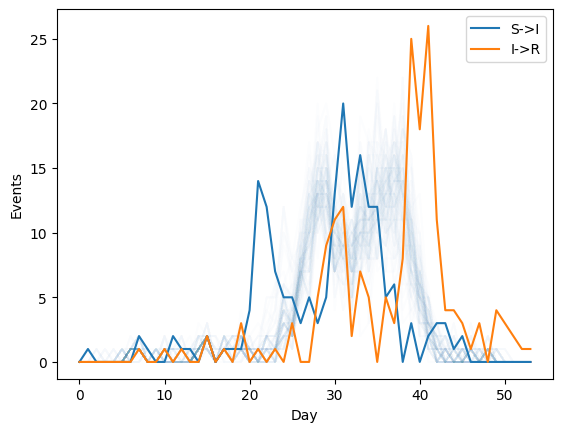

In [88]:
plt.plot(samples.sir[500::50,...,0].sum(axis=-1).T, color="C0", alpha=0.01)
plt.plot(events[...,0].sum(axis=-1), color="C0", label="S->I")
plt.plot(events[...,1].sum(axis=-1), color="C1", label="I->R")
plt.legend()
plt.xlabel("Day")
plt.ylabel("Events")

Interestingly, our model is suggesting that the _true_ infection times might be a little erroneous!  It is difficult to know in 2026 how accurate the epidemiology was in 1861 in Hagelloch, but it does give some food for thought as to whether the epidemiology or the model is wrong.  Probably both!

```{tip}
Gemlib has a standalone version of the `compute_state()` method that is auto-vectorised, so you can pass it an entire tensor of samples from an event list and initial conditions to compute the posterior samples over S, I, and R for all timepoints.
```

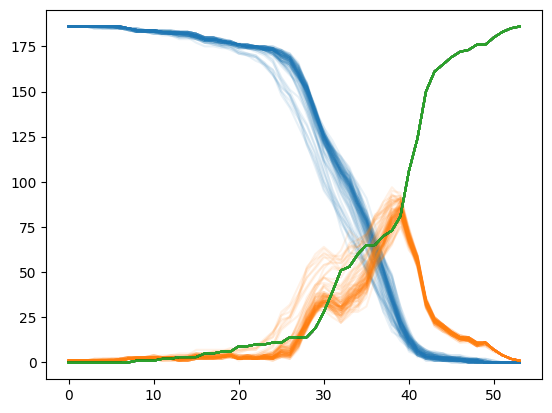

In [89]:
from gemlib.distributions.discrete_markov import compute_state

state_samples = compute_state(
    samples.initial_conditions[500::50], samples.sir[500::50], np.array(sir_incidence_matrix)
)

plt.plot(state_samples[...,0].sum(axis=-1).T, color="C0", alpha=0.1)
plt.plot(state_samples[...,1].sum(axis=-1).T, color="C1", alpha=0.1)
plt.plot(state_samples[...,2].sum(axis=-1).T, color="C2", alpha=0.1);


```{solution-end}
```